In [1]:
#getting all the necessary packaging
!pip install lifelines
import pandas as pd
import numpy as np
import lifelines
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import seaborn as sns
kmf=KaplanMeierFitter()

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [16]:
#Basic Data Management Steps
#loading in the data
autopsydata=pd.read_csv('Juric_Rapid_Autopsy_MASTER-participants.csv', sep='\t')
print(autopsydata.head(2))

#creating event column, useful for survival data
autopsydata['dead']=np.where(autopsydata['vital_status']=='dead', 1, 0)
print(autopsydata.head(2))

#making sure that the necessary numbers are in numeric form for when I run survival later
autopsydata['follow_up_date'] = pd.to_numeric(autopsydata['follow_up_date'])
autopsydata['dead']=pd.to_numeric(autopsydata['dead'])

#subset the carcinoma data
carcinoma=autopsydata[autopsydata['tumor_morphology'].str.contains('CHOLANGIOCARCINOMA', na=False) ]
print(carcinoma)

   db_id participant_id             aliases tumor_primary_site  \
0   6233        RA_1045  1045, RP-1700_1045       BREAST (C50)   
1   6234        RA_1078  1078, RP-1700_1078       BREAST (C50)   

                                    tumor_morphology tumor_molecular_subtype  \
0  C50  (8522/3 INFILTRATING DUCT AND LOBULAR CAR...           ER+/PR-/HER2-   
1       C50 (8521/3 INFILTRATING DUCTULAR CARCINOMA)           ER+/PR+/HER2-   

           biospecimen_type_count main_normal  gender     race  ...  \
0  Tumor: 30Normal: 1PBMC: 0NA: 0   T01375-16  female  unknown  ...   
1  Tumor: 15Normal: 1PBMC: 0NA: 0   T01097-24  female  unknown  ...   

   vital_status  death_date_dfd biospecimen_total_count treatment_count  \
0  not reported             NaN                      31              11   
1  not reported             NaN                      16              20   

   follow_up_date                                          notes  \
0          3105.0                                   

NameError: name 'gender' is not defined

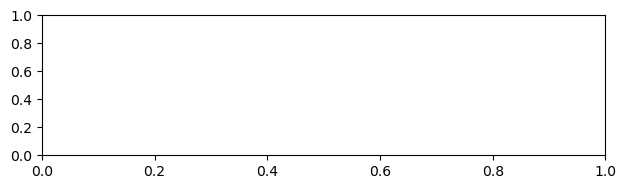

In [21]:
#Demographic Graphing

#Gender Pie Chart
plt.figure(figsize=(16,4))

plt.subplot(2,2, 1)
plt.pie(carcinoma, labels=gender, autopct='%1.1f%%', colors=['lightpink','lightskyblue','lightgray'])